# MyHinglishSentiment

Single-notebook Colab workflow: installs dependencies, writes `src/*.py`, trains, shows plots, optional Gradio.

**Runtime → Change runtime type → GPU** recommended. Run cells top to bottom (or Run all).


In [1]:
%pip install -q torch transformers datasets accelerate pandas scikit-learn matplotlib seaborn sentencepiece safetensors gradio tqdm ipython

import torch
print("CUDA:", torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else "")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.3 MB/s eta 0:00:00
CUDA: False 


In [2]:
import os
from pathlib import Path

ROOT = Path("/content/MyHinglishSentiment")
for sub in ("src", "data", "model", "outputs", "reports"):
    (ROOT / sub).mkdir(parents=True, exist_ok=True)
os.chdir(ROOT)
print(ROOT.resolve())


/content/MyHinglishSentiment


In [3]:
%%writefile /content/MyHinglishSentiment/src/__init__.py
"""MyHinglishSentiment — Hinglish sentiment classification package."""

__version__ = "1.0.0"


Writing /content/MyHinglishSentiment/src/__init__.py


In [4]:
%%writefile /content/MyHinglishSentiment/src/data_preparation.py
"""
Synthetic Lahore-style Roman Hinglish review generator and dataset utilities.

Generates a balanced CSV (1000 samples: ~334 positive, ~333 negative, ~333 neutral),
applies cleaning, and produces stratified train/validation/test splits (70/15/15).
"""

from __future__ import annotations

import argparse
import os
import random
import re
from pathlib import Path
from typing import List, Tuple

import pandas as pd
from sklearn.model_selection import train_test_split

# Reproducibility for dataset generation
RNG_SEED = 42

# ---------------------------------------------------------------------------
# Lahore / Pakistan-style Hinglish lexicon (Roman script)
# ---------------------------------------------------------------------------

POS_OPENERS = [
    "Yaar honestly",
    "Bhai dil se bolun",
    "Mast experience tha",
    "Lahore mein itna acha",
    "Seriously impressed",
    "Full paisa vasool",
    "Itna pyara",
    "Zabardast vibe",
    "Love ho gaya",
    "Dil khush ho gaya",
]

POS_MID = [
    "staff bohot cooperative tha",
    "food fresh aur tasty tha",
    "ambience on point thi",
    "service fast thi",
    "portion size bhi theek tha",
    "hygiene top notch thi",
    "family ke sath perfect tha",
    "music aur lighting balanced thi",
    "delivery time bhi reasonable tha",
    "packaging neat thi",
]

POS_CLOSERS = [
    "dobara zaroor aaunga.",
    "friends ko recommend karunga.",
    "full 10/10 vibes.",
    "dil se thank you team.",
    "next weekend phir plan banega.",
    "Lahore mein best lagta hai.",
    "value for money hai bilkul.",
    "maza aa gaya sach mein.",
]

NEG_OPENERS = [
    "Bhai disappointment hi disappointment",
    "Bekar experience raha",
    "Paisa zaya hogaya",
    "Itna ganda kabhi nahi dekha",
    "Seriously pathetic",
    "Time waste pura",
    "Expectations bilkul crush hogayeen",
    "Staff rude tha bilkul",
    "Quality neeche gir gayi",
    "Hype se zyada kuch nahi tha",
]

NEG_MID = [
    "order late aya aur thanda tha",
    "taste flat tha, masala missing",
    "portion chota tha price ke hisaab se",
    "hygiene questionable thi",
    "noise level unbearable tha",
    "billing mein extra charges add kiye",
    "wait time bohot zyada tha",
    "ambience dull aur congested thi",
    "packaging leak hogayi thi",
    "staff argue karne lag gaye",
]

NEG_CLOSERS = [
    "dobara kabhi nahi.",
    "recommend nahi karunga kisi ko.",
    "paise barbad mat karna.",
    "Lahore mein aur options dekh lo.",
    "1/10 bas.",
    "bekar hi bekar.",
    "sorry but sach hai.",
]

NEU_OPENERS = [
    "Theek tha overall",
    "Average sa experience tha",
    "Kuch khaas nahi, kuch bura bhi nahi",
    "Normal restaurant vibes",
    "Mixed feelings hain",
    "Neutral hi bolunga",
    "Itna acha bura dono nahi",
    "Standard expectation ke around tha",
    "Dekh lo agar pasand ho to",
    "Okay okay type tha",
]

NEU_MID = [
    "food average tha, edible tha",
    "service kabhi fast kabhi slow",
    "price thora high lag raha tha",
    "ambience simple thi",
    "taste expected jaisa hi tha",
    "portion size normal tha",
    "location convenient thi",
    "parking thori mushkil thi",
    "menu variety theek thi",
    "noise level manageable tha",
]

NEU_CLOSERS = [
    "try kar sakte ho agar nearby ho.",
    "maybe dobara sochunga.",
    "3.5/5 type feel.",
    "neither wow nor uff.",
    "bas chal jata hai.",
    "expectation medium rakho.",
]


def _pick(rng: random.Random, items: List[str]) -> str:
    return rng.choice(items)


def _maybe_prefix(rng: random.Random, text: str, p: float = 0.35) -> str:
    fillers = [
        "Assalamualaikum, ",
        "Hi bhai, ",
        "So basically ",
        "Quick review: ",
        "Lahore se likh raha hoon — ",
    ]
    if rng.random() < p:
        return rng.choice(fillers) + text
    return text


def _maybe_suffix(rng: random.Random, text: str, p: float = 0.3) -> str:
    tails = [
        " Bas itna hi.",
        " Thanks for reading yaar.",
        " Hope helpful ho.",
        " That's my honest take.",
        " Allah Hafiz.",
    ]
    if rng.random() < p:
        return text + rng.choice(tails)
    return text


def _build_positive_review(rng: random.Random) -> str:
    """Compose a positive Hinglish review with variable length."""
    style = rng.randint(0, 3)
    if style == 0:
        parts = [
            _pick(rng, POS_OPENERS) + ",",
            _pick(rng, POS_MID) + ",",
            _pick(rng, POS_MID) + ".",
            _pick(rng, POS_CLOSERS),
        ]
    elif style == 1:
        parts = [
            _pick(rng, POS_OPENERS) + "!",
            _pick(rng, POS_MID) + ".",
            _pick(rng, POS_CLOSERS),
        ]
    else:
        parts = [
            _pick(rng, POS_OPENERS) + ".",
            _pick(rng, POS_MID) + ",",
            _pick(rng, POS_MID) + ",",
            _pick(rng, POS_MID) + ".",
            _pick(rng, POS_CLOSERS),
        ]
    text = " ".join(parts)
    text = _maybe_prefix(rng, text)
    text = _maybe_suffix(rng, text)
    return clean_review_text(text)


def _build_negative_review(rng: random.Random) -> str:
    style = rng.randint(0, 3)
    if style == 0:
        parts = [
            _pick(rng, NEG_OPENERS) + ",",
            _pick(rng, NEG_MID) + ",",
            _pick(rng, NEG_MID) + ".",
            _pick(rng, NEG_CLOSERS),
        ]
    elif style == 1:
        parts = [
            _pick(rng, NEG_OPENERS) + "!",
            _pick(rng, NEG_MID) + ".",
            _pick(rng, NEG_CLOSERS),
        ]
    else:
        parts = [
            _pick(rng, NEG_OPENERS) + ".",
            _pick(rng, NEG_MID) + ",",
            _pick(rng, NEG_MID) + ",",
            _pick(rng, NEG_MID) + ".",
            _pick(rng, NEG_CLOSERS),
        ]
    text = " ".join(parts)
    text = _maybe_prefix(rng, text)
    text = _maybe_suffix(rng, text)
    return clean_review_text(text)


def _build_neutral_review(rng: random.Random) -> str:
    style = rng.randint(0, 3)
    if style == 0:
        parts = [
            _pick(rng, NEU_OPENERS) + ",",
            _pick(rng, NEU_MID) + ",",
            _pick(rng, NEU_MID) + ".",
            _pick(rng, NEU_CLOSERS),
        ]
    elif style == 1:
        parts = [
            _pick(rng, NEU_OPENERS) + ".",
            _pick(rng, NEU_MID) + ".",
            _pick(rng, NEU_CLOSERS),
        ]
    else:
        parts = [
            _pick(rng, NEU_OPENERS) + "!",
            _pick(rng, NEU_MID) + ",",
            _pick(rng, NEU_MID) + ",",
            _pick(rng, NEU_MID) + ".",
            _pick(rng, NEU_CLOSERS),
        ]
    text = " ".join(parts)
    text = _maybe_prefix(rng, text)
    text = _maybe_suffix(rng, text)
    return clean_review_text(text)


def clean_review_text(text: str) -> str:
    """
    Normalize whitespace, strip junk characters, keep basic Roman + digits + punctuation.
    """
    if not isinstance(text, str):
        text = str(text)
    text = text.replace("\u200b", "").replace("\ufeff", "")
    text = text.strip()
    # Collapse repeated spaces
    text = re.sub(r"\s+", " ", text)
    # Remove excessive repeated punctuation
    text = re.sub(r"([!?.,]){3,}", r"\1\1", text)
    return text.strip()


def generate_synthetic_dataset(
    n_positive: int = 334,
    n_negative: int = 333,
    n_neutral: int = 333,
    seed: int = RNG_SEED,
) -> pd.DataFrame:
    """
    Build a balanced synthetic Hinglish dataset (default total = 1000 rows).

    Returns columns: review_text, sentiment (string labels).
    """
    rng = random.Random(seed)
    rows: List[Tuple[str, str]] = []

    for _ in range(n_positive):
        rows.append((_build_positive_review(rng), "positive"))
    for _ in range(n_negative):
        rows.append((_build_negative_review(rng), "negative"))
    for _ in range(n_neutral):
        rows.append((_build_neutral_review(rng), "neutral"))

    rng.shuffle(rows)
    df = pd.DataFrame(rows, columns=["review_text", "sentiment"])
    df["review_text"] = df["review_text"].map(clean_review_text)
    return df.reset_index(drop=True)


def stratified_split(
    df: pd.DataFrame,
    label_col: str = "sentiment",
    test_size: float = 0.15,
    val_size_within_train: float = 0.15 / 0.85,
    seed: int = RNG_SEED,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    70/15/15 train/val/test split with stratification on `label_col`.
    """
    train_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=seed,
        stratify=df[label_col],
    )
    train_df, val_df = train_test_split(
        train_df,
        test_size=val_size_within_train,
        random_state=seed,
        stratify=train_df[label_col],
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)


def save_csv(df: pd.DataFrame, path: str | Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False, encoding="utf-8")


def load_csv(path: str | Path) -> pd.DataFrame:
    return pd.read_csv(path, encoding="utf-8")


def ensure_dataset(
    output_csv: str | Path,
    regenerate: bool = False,
) -> pd.DataFrame:
    """
    Generate synthetic data if missing or if regenerate=True.
    """
    output_csv = Path(output_csv)
    if output_csv.exists() and not regenerate:
        return load_csv(output_csv)
    df = generate_synthetic_dataset()
    save_csv(df, output_csv)
    return df


def main() -> None:
    parser = argparse.ArgumentParser(description="Generate hinglish_reviews.csv")
    parser.add_argument(
        "--out",
        type=str,
        default="data/hinglish_reviews.csv",
        help="Output CSV path",
    )
    parser.add_argument("--seed", type=int, default=RNG_SEED)
    parser.add_argument("--force", action="store_true", help="Overwrite existing CSV")
    args = parser.parse_args()

    out_path = Path(args.out)
    if out_path.exists() and not args.force:
        print(f"Dataset already exists at {out_path}. Use --force to regenerate.")
        return

    df = generate_synthetic_dataset(seed=args.seed)
    save_csv(df, out_path)
    print(f"Saved {len(df)} rows to {out_path}")
    print(df["sentiment"].value_counts())


if __name__ == "__main__":
    main()


Writing /content/MyHinglishSentiment/src/data_preparation.py


In [5]:
%%writefile /content/MyHinglishSentiment/src/train.py
"""
Fine-tune XLM-RoBERTa for Hinglish sentiment (3-class) using Hugging Face Trainer.

Steps:
  1. Ensure/generate data/hinglish_reviews.csv
  2. Stratified 70/15/15 split
  3. Tokenize + train with early stopping
  4. Evaluate on test set, save plots + confusion matrix + classification report
  5. Save model to model/
"""

from __future__ import annotations

import argparse
import inspect
import json
import random
import sys
from pathlib import Path
from typing import Any, Dict

# Ensure `src/` is importable when launched as `python -m src.train` from project root
_SRC_DIR = Path(__file__).resolve().parent
if str(_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(_SRC_DIR))

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    EvalPrediction,
    Trainer,
    TrainingArguments,
)

from data_preparation import clean_review_text, ensure_dataset, stratified_split

# Label mapping (fixed for reproducibility)
LABEL2ID = {"negative": 0, "neutral": 1, "positive": 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}


def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def get_device_info() -> str:
    if torch.cuda.is_available():
        return f"CUDA: {torch.cuda.get_device_name(0)}"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return "MPS (Apple Silicon)"
    return "CPU"


def preprocess_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """Clean text and map string labels to integers."""
    out = df.copy()
    out["review_text"] = out["review_text"].astype(str).map(clean_review_text)
    out["labels"] = out["sentiment"].map(LABEL2ID)
    out = out.dropna(subset=["labels"])
    out["labels"] = out["labels"].astype(int)
    return out


def tokenize_batch(examples: Dict[str, Any], tokenizer: AutoTokenizer, max_length: int) -> Dict[str, Any]:
    enc = tokenizer(
        examples["review_text"],
        truncation=True,
        padding="max_length",
        max_length=max_length,
    )
    # Keep labels explicit for batched `.map()` (column merge behavior)
    enc["labels"] = examples["labels"]
    return enc


def compute_metrics_builder():
    def compute_metrics(eval_pred: EvalPrediction) -> Dict[str, float]:
        logits, labels = eval_pred
        preds = np.argmax(logits, axis=-1)
        acc = accuracy_score(labels, preds)
        f1_w = f1_score(labels, preds, average="weighted")
        f1_macro = f1_score(labels, preds, average="macro")
        return {"accuracy": acc, "f1_weighted": f1_w, "f1_macro": f1_macro}

    return compute_metrics


def plot_training_history(log_history: list, out_dir: Path) -> None:
    """Plot loss and accuracy from Trainer state log."""
    out_dir.mkdir(parents=True, exist_ok=True)
    steps = []
    train_loss = []
    eval_loss = []
    eval_acc = []

    for entry in log_history:
        if "loss" in entry and "epoch" in entry:
            steps.append(entry.get("step", len(steps)))
            train_loss.append(entry["loss"])
        if "eval_loss" in entry:
            eval_loss.append(entry["eval_loss"])
            eval_acc.append(entry.get("eval_accuracy", np.nan))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if train_loss:
        axes[0].plot(range(len(train_loss)), train_loss, label="Train loss", color="#2563eb")
    if eval_loss:
        axes[0].plot(
            np.linspace(0, len(train_loss) - 1 if train_loss else 1, len(eval_loss)),
            eval_loss,
            label="Validation loss",
            color="#dc2626",
            marker="o",
        )
    axes[0].set_title("Loss curves")
    axes[0].set_xlabel("Logging steps (train) / eval points")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    if eval_acc and not all(np.isnan(eval_acc)):
        axes[1].plot(eval_acc, label="Validation accuracy", color="#059669", marker="o")
        axes[1].set_title("Validation accuracy")
        axes[1].set_xlabel("Evaluation epoch index")
        axes[1].set_ylim(0.0, 1.05)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, "No eval accuracy in log", ha="center")

    plt.tight_layout()
    plt.savefig(out_dir / "training_history.png", dpi=150)
    plt.close()


def plot_confusion_matrix_heatmap(cm: np.ndarray, labels: list[str], out_path: Path) -> None:
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.title("Confusion matrix (test set)")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150)
    plt.close()


def train_and_evaluate(
    csv_path: Path,
    model_out: Path,
    output_dir: Path,
    model_name: str = "xlm-roberta-base",
    max_length: int = 128,
    num_epochs: int = 10,
    batch_size: int = 16,
    learning_rate: float = 2e-5,
    seed: int = 42,
    early_stopping_patience: int = 3,
) -> Dict[str, Any]:
    set_seed(seed)

    df = ensure_dataset(csv_path, regenerate=False)
    df = preprocess_dataframe(df)

    train_df, val_df, test_df = stratified_split(df, label_col="sentiment", seed=seed)

    print("\n=== Dataset splits (stratified 70/15/15) ===")
    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    print("Train sentiment counts:\n", train_df["sentiment"].value_counts())

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    train_ds = Dataset.from_pandas(train_df[["review_text", "labels"]])
    val_ds = Dataset.from_pandas(val_df[["review_text", "labels"]])
    test_ds = Dataset.from_pandas(test_df[["review_text", "labels"]])

    def _tok(examples):
        return tokenize_batch(examples, tokenizer, max_length)

    train_ds = train_ds.map(_tok, batched=True, remove_columns=["review_text"])
    val_ds = val_ds.map(_tok, batched=True, remove_columns=["review_text"])
    test_ds = test_ds.map(_tok, batched=True, remove_columns=["review_text"])

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(LABEL2ID),
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )

    num_labels = len(LABEL2ID)

    use_fp16 = torch.cuda.is_available()
    # TrainingArguments: `eval_strategy` vs `evaluation_strategy` across transformers versions
    ta_kwargs: Dict[str, Any] = dict(
        output_dir=str(output_dir / "checkpoints"),
        save_strategy="epoch",
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        weight_decay=0.01,
        logging_steps=25,
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
        greater_is_better=True,
        save_total_limit=2,
        seed=seed,
        fp16=use_fp16,
        report_to="none",
    )
    sig_ta = inspect.signature(TrainingArguments.__init__)
    if "eval_strategy" in sig_ta.parameters:
        ta_kwargs["eval_strategy"] = "epoch"
    else:
        ta_kwargs["evaluation_strategy"] = "epoch"
    # Warmup: prefer explicit steps on newer Transformers (warmup_ratio deprecated in v5.2+)
    steps_per_epoch = max(1, len(train_ds) // batch_size)
    total_opt_steps = max(1, steps_per_epoch * num_epochs)
    warmup_steps = max(1, int(total_opt_steps * 0.1))
    if "warmup_steps" in sig_ta.parameters:
        ta_kwargs["warmup_steps"] = warmup_steps
    elif "warmup_ratio" in sig_ta.parameters:
        ta_kwargs["warmup_ratio"] = 0.1

    training_args = TrainingArguments(**ta_kwargs)

    trainer_kw: Dict[str, Any] = dict(
        model=model,
        args=training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        compute_metrics=compute_metrics_builder(),
        callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience)],
    )
    sig_tr = inspect.signature(Trainer.__init__)
    if "tokenizer" in sig_tr.parameters:
        trainer_kw["tokenizer"] = tokenizer
    elif "processing_class" in sig_tr.parameters:
        trainer_kw["processing_class"] = tokenizer
    trainer = Trainer(**trainer_kw)

    print(f"\n=== Training on device: {get_device_info()} ===\n")
    train_result = trainer.train()
    print("\n=== Training complete ===\n")

    # Test evaluation
    predictions = trainer.predict(test_ds)
    logits = predictions.predictions
    y_true = predictions.label_ids
    y_pred = np.argmax(logits, axis=-1)

    test_acc = accuracy_score(y_true, y_pred)
    report = classification_report(
        y_true,
        y_pred,
        target_names=[ID2LABEL[i] for i in range(num_labels)],
        digits=4,
    )
    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_labels)))

    print("\n" + "=" * 60)
    print("TEST SET RESULTS")
    print("=" * 60)
    print(f"Test accuracy: {test_acc * 100:.2f}%")
    print("\nClassification report:\n")
    print(report)
    print("\nConfusion matrix (rows=true, cols=pred):\n")
    print(cm)

    # Plots
    plot_training_history(trainer.state.log_history, output_dir)
    plot_confusion_matrix_heatmap(
        cm,
        [ID2LABEL[i] for i in range(num_labels)],
        output_dir / "confusion_matrix.png",
    )

    # Save metrics JSON
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=list(range(num_labels)))
    metrics_payload = {
        "test_accuracy": float(test_acc),
        "per_class": {
            ID2LABEL[i]: {"precision": float(prec[i]), "recall": float(rec[i]), "f1": float(f1[i])}
            for i in range(num_labels)
        },
        "model_name": model_name,
    }
    with open(output_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics_payload, f, indent=2)

    # Save model + tokenizer + label config for inference
    model_out.mkdir(parents=True, exist_ok=True)
    trainer.save_model(str(model_out))
    tokenizer.save_pretrained(str(model_out))
    label_cfg = {"id2label": {str(k): v for k, v in ID2LABEL.items()}, "label2id": LABEL2ID}
    with open(model_out / "label_config.json", "w", encoding="utf-8") as f:
        json.dump(label_cfg, f, indent=2)

    return {
        "test_accuracy": test_acc,
        "classification_report": report,
        "train_loss": getattr(train_result, "training_loss", None),
        "output_dir": str(output_dir),
        "model_dir": str(model_out),
    }


def parse_args() -> argparse.Namespace:
    root = Path(__file__).resolve().parent.parent
    p = argparse.ArgumentParser(description="Train Hinglish sentiment classifier")
    p.add_argument("--data", type=str, default=str(root / "data" / "hinglish_reviews.csv"))
    p.add_argument("--model-out", type=str, default=str(root / "model"))
    p.add_argument("--output-dir", type=str, default=str(root / "outputs"))
    p.add_argument("--model-name", type=str, default="xlm-roberta-base")
    p.add_argument("--epochs", type=int, default=10)
    p.add_argument("--batch-size", type=int, default=16)
    p.add_argument("--lr", type=float, default=2e-5)
    p.add_argument("--max-length", type=int, default=128)
    p.add_argument("--seed", type=int, default=42)
    p.add_argument("--regenerate-data", action="store_true", help="Regenerate synthetic CSV before training")
    return p.parse_args()


def main() -> None:
    args = parse_args()
    csv_path = Path(args.data)
    if args.regenerate_data:
        from data_preparation import generate_synthetic_dataset, save_csv

        save_csv(generate_synthetic_dataset(seed=args.seed), csv_path)

    ensure_dataset(csv_path, regenerate=False)

    results = train_and_evaluate(
        csv_path=csv_path,
        model_out=Path(args.model_out),
        output_dir=Path(args.output_dir),
        model_name=args.model_name,
        max_length=args.max_length,
        num_epochs=args.epochs,
        batch_size=args.batch_size,
        learning_rate=args.lr,
        seed=args.seed,
    )

    print("\nArtifacts saved:")
    print(f"  Model: {results['model_dir']}")
    print(f"  Plots & metrics: {results['output_dir']}")


if __name__ == "__main__":
    main()


Writing /content/MyHinglishSentiment/src/train.py


In [6]:
%%writefile /content/MyHinglishSentiment/src/inference.py
"""
Load a fine-tuned model for Hinglish sentiment inference with confidence scores.
"""

from __future__ import annotations

import json
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# Default label order must match training
ID2LABEL = {0: "negative", 1: "neutral", 2: "positive"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


class HinglishSentimentPredictor:
    """Thin wrapper around HF tokenizer + sequence classification model."""

    def __init__(self, model_dir: str | Path, device: torch.device | None = None) -> None:
        self.model_dir = Path(model_dir)
        self.device = device or get_device()
        self.tokenizer = AutoTokenizer.from_pretrained(self.model_dir)
        self.model = AutoModelForSequenceClassification.from_pretrained(self.model_dir)
        self.model.to(self.device)
        self.model.eval()

        # Prefer saved label maps if present
        config_path = self.model_dir / "label_config.json"
        if config_path.exists():
            with open(config_path, "r", encoding="utf-8") as f:
                cfg = json.load(f)
            self.id2label = {int(k): v for k, v in cfg["id2label"].items()}
            self.label2id = cfg["label2id"]
        else:
            self.id2label = ID2LABEL
            self.label2id = LABEL2ID

    @torch.inference_mode()
    def predict(self, text: str, max_length: int = 128) -> Dict[str, Any]:
        """Return predicted label, confidence, and full probability vector."""
        enc = self.tokenizer(
            text,
            truncation=True,
            padding=True,
            max_length=max_length,
            return_tensors="pt",
        )
        enc = {k: v.to(self.device) for k, v in enc.items()}
        logits = self.model(**enc).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        pred_id = int(np.argmax(probs))
        label = self.id2label[pred_id]
        confidence = float(probs[pred_id])
        return {
            "label": label,
            "confidence": confidence,
            "probabilities": {self.id2label[i]: float(probs[i]) for i in range(len(probs))},
        }

    def predict_batch(self, texts: List[str], max_length: int = 128) -> List[Dict[str, Any]]:
        return [self.predict(t, max_length=max_length) for t in texts]


def load_predictor(model_dir: str | Path | None = None) -> HinglishSentimentPredictor:
    """Load predictor from `model/` relative to project root by default."""
    root = Path(__file__).resolve().parent.parent
    path = Path(model_dir) if model_dir else root / "model"
    return HinglishSentimentPredictor(path)


Writing /content/MyHinglishSentiment/src/inference.py


In [8]:
%cd /content/MyHinglishSentiment
!python src/train.py --epochs 10 --batch-size 16 --lr 2e-5


/content

=== Dataset splits (stratified 70/15/15) ===
Train: 700 | Val: 150 | Test: 150
Train sentiment counts:
 sentiment
positive    234
neutral     233
negative    233
Name: count, dtype: int64
Map: 100% 700/700 [00:00<00:00, 5804.90 examples/s]
Map: 100% 150/150 [00:00<00:00, 5943.24 examples/s]
Map: 100% 150/150 [00:00<00:00, 6227.87 examples/s]
Loading weights: 100% 197/197 [00:00<00:00, 555.71it/s, Materializing param=roberta.encoder.layer.11.output.dense.weight]
XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.de

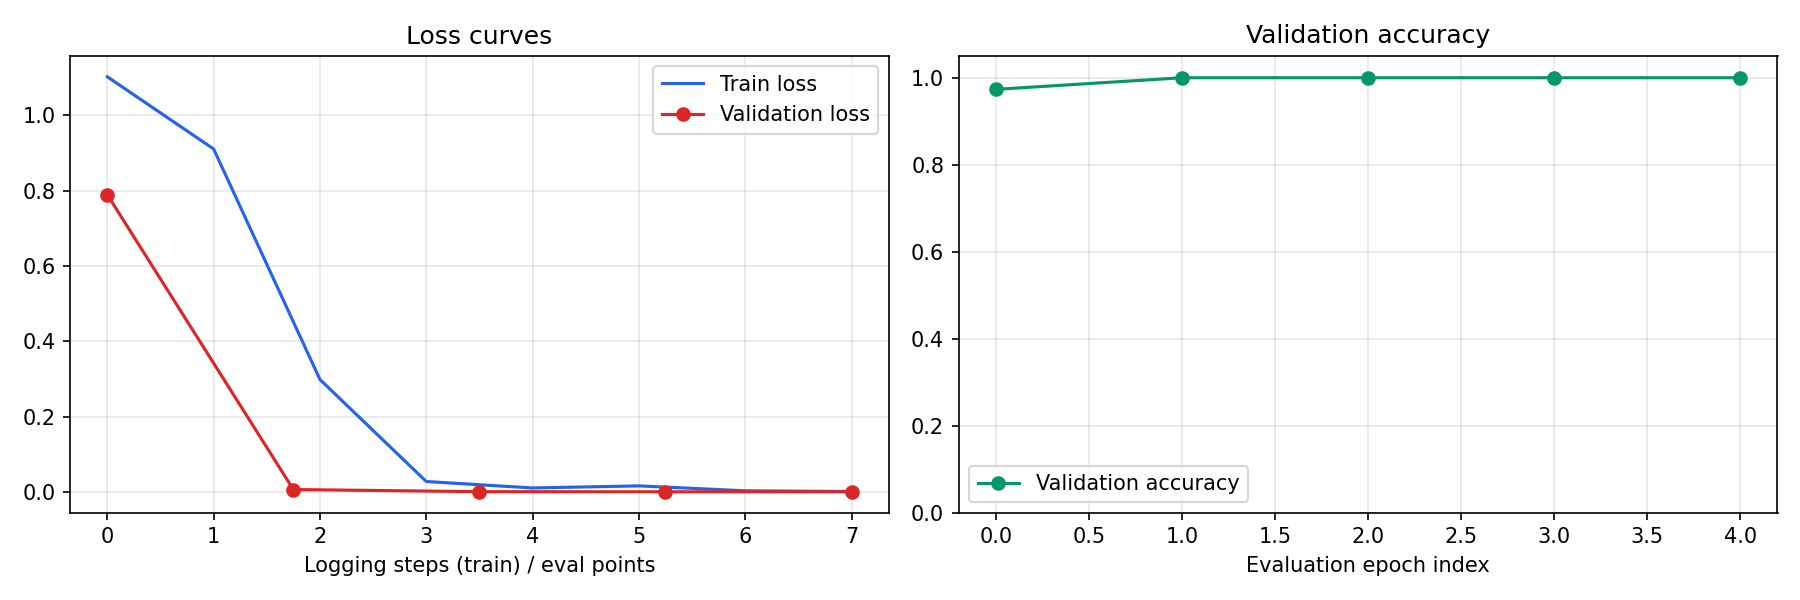

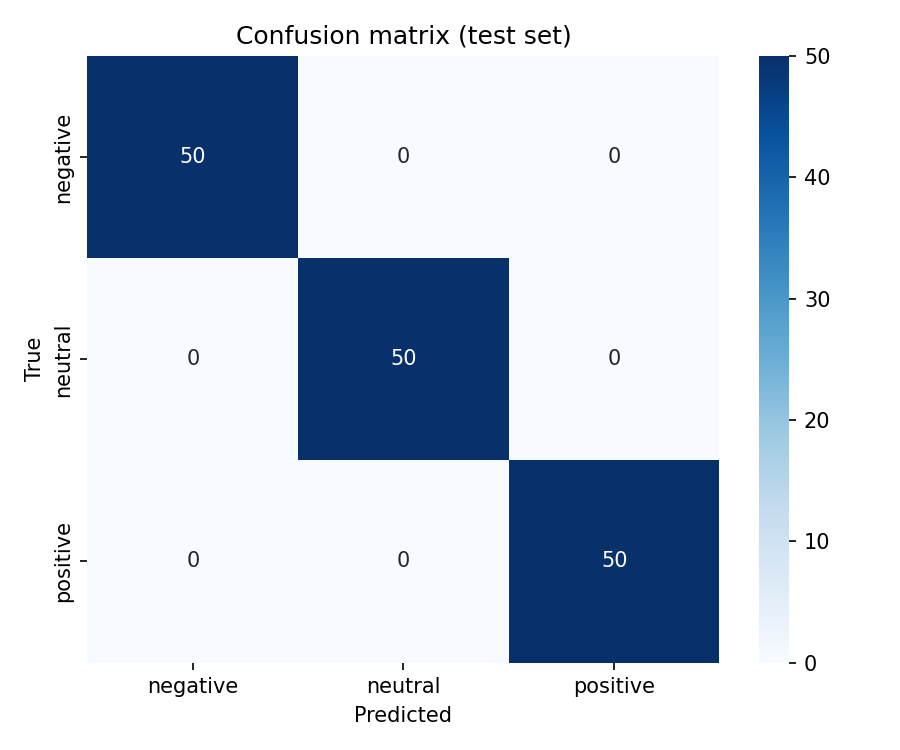

{
  "test_accuracy": 1.0,
  "per_class": {
    "negative": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0
    },
    "neutral": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0
    },
    "positive": {
      "precision": 1.0,
      "recall": 1.0,
      "f1": 1.0
    }
  },
  "model_name": "xlm-roberta-base"
}


In [9]:
from IPython.display import Image, display
from pathlib import Path
import json

out = Path("/content/MyHinglishSentiment") / "outputs"
for name in ("training_history.png", "confusion_matrix.png"):
    p = out / name
    if p.exists():
        display(Image(filename=str(p)))
m = out / "metrics.json"
print(json.dumps(json.loads(m.read_text(encoding="utf-8")), indent=2) if m.exists() else "No metrics.json yet.")


In [10]:
import os, sys
os.chdir("/content/MyHinglishSentiment")
sys.path.insert(0, "/content/MyHinglishSentiment/src")
import gradio as gr
from inference import HinglishSentimentPredictor

pred = HinglishSentimentPredictor("/content/MyHinglishSentiment/model")
EMO = {"positive": "😊", "negative": "😞", "neutral": "😐"}

def go(text):
    text = (text or "").strip()
    if not text:
        return "Enter text."
    o = pred.predict(text)
    e = EMO.get(o["label"], "")
    nl = chr(10)
    lines = [f"{k}: {v * 100:.1f}%" for k, v in o["probabilities"].items()]
    probs = nl.join(lines)
    head = f"{e} **{o['label'].upper()}** — confidence {o['confidence'] * 100:.1f}%"
    return head + nl + nl + probs

demo = gr.Interface(fn=go, inputs=gr.Textbox(lines=4, label="Hinglish review"), outputs=gr.Markdown())
demo.launch(share=True)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aa9b7e97b8f1672de3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
